In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [3]:
url = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'
ds = xr.open_dataset(url)

# select period
#ds = ds.sel(time=slice('1960', '2020'))
#ds

#actually load the data
ds.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2031, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-03-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2023-04-04
    DODS_EXTRA.Unlimited_Dimension:  time

In [ ]:
print(ds['time'])

In [ ]:
#select month 
ds = ds.sel(time=ds.time.dt.month.isin([1, 2, 3, 4, 11, 12])) #winter half year
ds

In [ ]:
#select domain
dsdo = ds.sel(lat=slice(5, -5), lon=slice(120, 180))
dsdo_mean = dsdo.mean(dim=('lon', 'lat'))
dsdo_mean

In [ ]:
#select period
dsdo_early = dsdo_mean.sel(time = slice('1900', '1950'))
dsdo_later = dsdo_mean.sel(time = slice('1960', '2020'))

In [ ]:
## first plot the averages for the first 10 years in blue


plt.hist(dsdo_early['sst'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1900-1950")
plt.hist(dsdo_later['sst'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1960-2020")


## then add a legend
plt.legend()

In [49]:
ds11 = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\air.mon.mean.nc")

ds11.load()

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 903)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1948-01-01 1948-02-01 ... 2023-03-01
Data variables:
    air      (time, lat, lon) float32 -34.93 -34.93 -34.93 ... -42.79 -42.79
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [50]:
print(ds11['air'])

<xarray.DataArray 'air' (time: 903, lat: 73, lon: 144)>
array([[[-34.926773, -34.926773, -34.926773, ..., -34.926773,
         -34.926773, -34.926773],
        [-35.13935 , -35.129673, -35.12742 , ..., -35.188705,
         -35.170002, -35.14935 ],
        [-34.352573, -34.04226 , -33.768707, ..., -35.333866,
         -35.002903, -34.671288],
        ...,
        [-16.525156, -16.404509, -16.284832, ..., -16.795155,
         -16.737736, -16.643543],
        [-16.190313, -16.202248, -16.21677 , ..., -16.132574,
         -16.161928, -16.178377],
        [-17.697733, -17.697733, -17.697733, ..., -17.697733,
         -17.697733, -17.697733]],

       [[-33.311375, -33.311375, -33.311375, ..., -33.311375,
         -33.311375, -33.311375],
        [-34.65034 , -34.476204, -34.29689 , ..., -35.18448 ,
         -35.009308, -34.835514],
        [-34.1031  , -33.619995, -33.161373, ..., -35.606552,
         -35.103443, -34.602757],
...
        [-34.189293, -33.990192, -33.748226, ..., -34.42144 ,

In [51]:
#select month 
ds11 = ds11.sel(time=ds.time.dt.month.isin([1, 2, 3, 4, 11, 12])) #winter half year
ds11

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 453)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1948-01-01 1948-02-01 ... 2023-03-01
Data variables:
    air      (time, lat, lon) float32 -34.93 -34.93 -34.93 ... -42.79 -42.79
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [52]:
#select domain
dsdo_tai = ds11.sel(lat=slice(26, 20), lon=slice(118, 125))
dsdo_mean_tai = dsdo_tai.mean(dim=('lon', 'lat'))
dsdo_mean_tai

<xarray.Dataset>
Dimensions:  (time: 453)
Coordinates:
  * time     (time) datetime64[ns] 1948-01-01 1948-02-01 ... 2023-03-01
Data variables:
    air      (time) float32 17.89 19.82 20.86 23.26 ... 20.87 19.51 20.26 21.33

In [53]:
#select period
dsdo_early_tai = dsdo_mean_tai.sel(time = slice('1980', '1999'))
dsdo_early_tai_2 = dsdo_mean_tai.sel(time = slice('1990', '2020'))
dsdo_later_tai = dsdo_mean_tai.sel(time = slice('2000', '2020'))

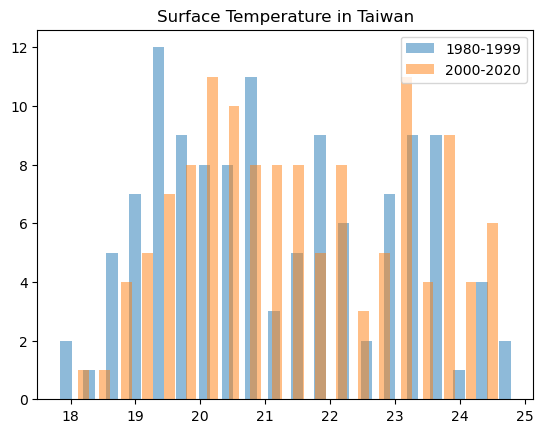

In [54]:
## first plot the averages for the first 10 years in blue

plt.hist(dsdo_early_tai['air'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1980-1999")
plt.hist(dsdo_later_tai['air'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "2000-2020")
plt.title("Surface Temperature in Taiwan")

## then add a legend
plt.legend()

In [59]:
#select domain
dsdo_ha = ds11.sel(lat=slice(20), lon=slice(205))
dsdo_mean_ha = dsdo_ha.mean(dim=('lon', 'lat'))
dsdo_mean_ha

<xarray.Dataset>
Dimensions:  (time: 453)
Coordinates:
  * time     (time) datetime64[ns] 1948-01-01 1948-02-01 ... 2023-03-01
Data variables:
    air      (time) float32 -9.73 -9.012 -5.936 0.2542 ... -7.576 -6.195 -3.702

In [66]:
#select period
dsdo_early_ha = dsdo_mean_ha.sel(time = slice('1980', '1999'))
dsdo_early_ha_2 = dsdo_mean_ha.sel(time = slice('1990', '2020'))
dsdo_later_ha = dsdo_mean_ha.sel(time = slice('2000', '2020'))

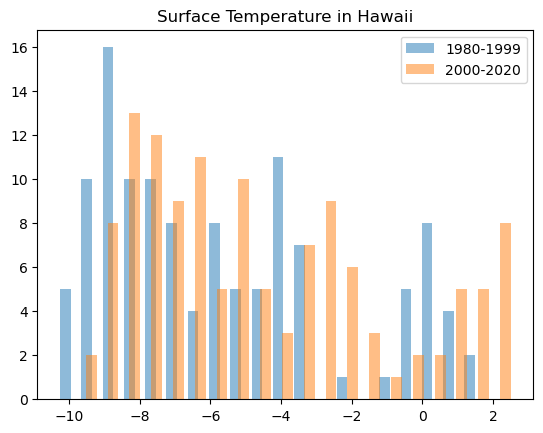

In [69]:
## first plot the averages for the first 10 years in blue

plt.hist(dsdo_early_ha['air'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1980-1999")
plt.hist(dsdo_later_ha['air'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "2000-2020")

plt.title("Surface Temperature in Hawaii")
## then add a legend
plt.legend()

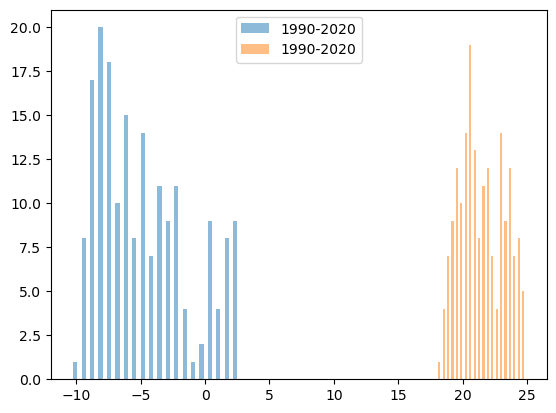

In [65]:
## first plot the averages for the first 10 years in blue

plt.hist(dsdo_early_ha_2['air'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1990-2020")
plt.hist(dsdo_early_tai_2['air'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1990-2020")


## then add a legend
plt.legend()

In [11]:
ur2 = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/gpcp/precip.mon.mean.nc'
ds2 = xr.open_dataset(ur2)

# select period
#ds = ds.sel(time=slice('1960', '2020'))
#ds

#actually load the data
ds2.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 530, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-02-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-03-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1313 0.1336 0.1373
Attributes: (12/20)
    Conventions:                     CF-1.0
    curator:                         Dr. Jian-Jian Wang\nESSIC, University of...
    citation:                        Adler, R.F., G.J. Huffman, A. Chang, R. ...
    title:                           GPCP Version 2.3 Combined Precipitation ...
    platform:                        NOAA POES (Polar Orbiting Environmental ...
    source_obs:                      CDR RSS SSMI/SSMIS Tbs over ocean \nCDR ...
    ...                              ...
    NCO:                             4.6.9
    history:                         Generated at NOAA/ESRL PSD Sep 9 2016 ba...
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    _NCProperties:                   version=2,netcdf=4.7.3,hdf5=1.10.6,
    data_comment:                    Interim data covers 2023/01 through latest.
    DODS_EXTRA.Unlimited_Dimension:  time

In [12]:
print(ds2['precip'])

<xarray.DataArray 'precip' (time: 530, lat: 72, lon: 144)>
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [9.81240392e-01, 9.32018101e-01, 8.13806593e-01, ...,
         9.16150570e-01, 8.11866999e-01, 9.01728511e-01],
        [7.49975920e-01, 7.74539351e-01, 6.70798063e-01, ...,
         6.94545209e-01, 7.39840150e-01, 7.66188383e-01],
        [6.61472678e-01, 5.77345729e-01, 6.17506027e-01, ...,
         5.72816312e-01, 6.05900526e-01, 7.07668364e-01]],

       [[3.36575955e-01, 3.16594929e-01, 3.24471772e-01, ...,
         2.84731507e-01, 2.96035439e-01, 3.03081393e-01],
        [2.57157892e-01, 2.81210452e-01, 2.83164263e-01, ...,
         2.59394765e-01,

In [139]:
#select month 
#ds2 = ds2.sel(time=ds2.time.dt.month.isin([1, 2, 3, 4, 11, 12])) #winter half year
#ds2

In [13]:
#select domain
prec_tai = ds2.sel(lat=slice(20, 26), lon=slice(118, 125))
prec_mean_tai = prec_tai.mean(dim=('lon', 'lat'))
prec_mean_tai

<xarray.Dataset>
Dimensions:    (time: 530, nv: 2)
Coordinates:
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-02-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-03-01
    lat_bnds   (nv) float32 21.25 23.75
    lon_bnds   (nv) float32 120.0 122.5
    precip     (time) float32 1.592 1.525 2.688 2.879 ... 1.691 1.735 1.903

In [14]:
#select period
prec_early_tai = prec_mean_tai.sel(time = slice('1980', '1999'))
prec_early_tai_2 = prec_mean_tai.sel(time = slice('1990', '2020'))
prec_later_tai = prec_mean_tai.sel(time = slice('2000', '2020'))

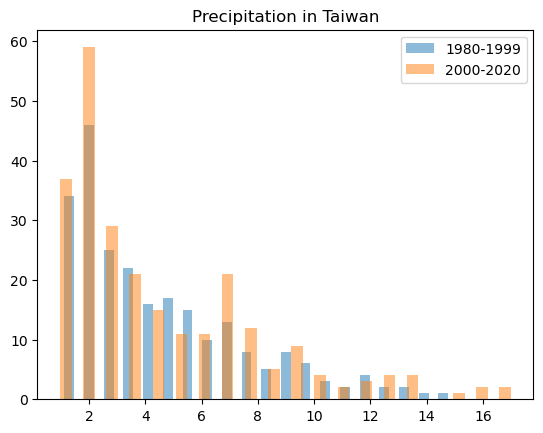

In [40]:
## first plot the averages for the first 10 years in blue

plt.hist(prec_early_tai['precip'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1980-1999")
plt.hist(prec_later_tai['precip'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "2000-2020")
plt.title("Precipitation in Taiwan" )

## then add a legend
plt.legend()

In [16]:
#select domain
prec_ha = ds2.sel(lat=slice(20), lon=slice(205))
prec_mean_ha = prec_ha.mean(dim=('lon', 'lat'))
prec_mean_ha

<xarray.Dataset>
Dimensions:    (time: 530, nv: 2)
Coordinates:
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-02-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-03-01
    lat_bnds   (nv) float32 -36.25 -33.75
    lon_bnds   (nv) float32 101.2 103.8
    precip     (time) float32 2.558 2.788 2.729 2.623 ... 2.402 2.681 2.77 2.846

In [17]:
#select period
prec_early_ha = prec_mean_ha.sel(time = slice('1990', '2020'))
prec_later_ha = prec_mean_ha.sel(time = slice('2000', '2020'))

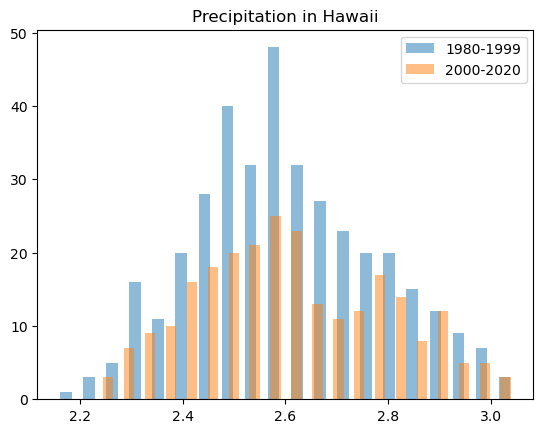

In [18]:
## first plot the averages for the first 10 years in blue

plt.hist(prec_early_ha['precip'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "1980-1999")
plt.hist(prec_later_ha['precip'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "2000-2020")
plt.title("Precipitation in Hawaii" )

## then add a legend
plt.legend()

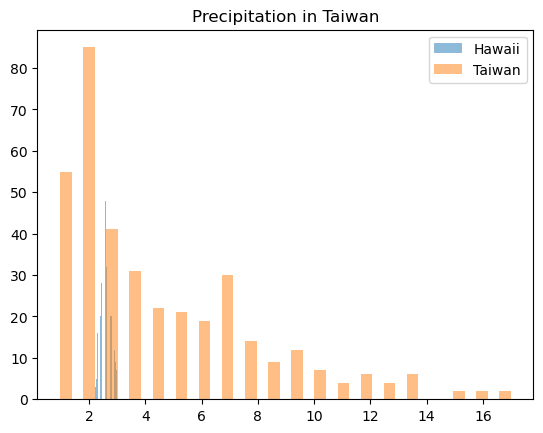

In [19]:
## first plot the averages for the first 10 years in blue

plt.hist(prec_early_ha['precip'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "Hawaii")
plt.hist(prec_early_tai_2['precip'], bins = 20, histtype = 'bar',density = False, alpha = 0.5, rwidth = 0.5, label = "Taiwan")
plt.title("Precipitation in Taiwan" )



## then add a legend
plt.legend()

In [20]:
# Make anomalies
ds_climo = ds2.groupby('time.month').mean()
ds_anoms = ds2.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, time: 530, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-02-01
    month     (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 4 5 6 7 8 9 10 11 12 1 2
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (time, lat, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_bnds  (time, lon, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip    (time, lat, lon) float32 -0.02229 -0.03102 ... -0.1812 -0.1707

In [21]:
# choose one point timeseries
pt_tai = ds_anoms.sel(lat = 23.5,lon = 120,method='nearest')
pt_ha = ds_anoms.sel(lat = 20,lon = 205,method='nearest')

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future 

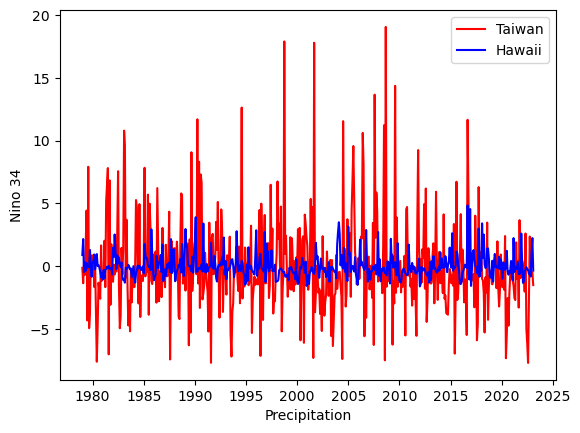

In [22]:
#line plot 
plt.plot(pt_tai['time'],pt_tai['precip'],'r')
plt.plot(pt_ha['time'],pt_ha['precip'],'b')

plt.xlabel("Precipitation")
plt.ylabel("Nino 34")
plt.legend(['Taiwan','Hawaii'])

In [23]:
ds3 = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
ds3

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    sst        (time, lat, lon) float32 ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [24]:
#make anomaly
sst_clim = ds3.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds3.sst.groupby('time.month') - sst_clim

In [25]:
sst_anom

<xarray.DataArray 'sst' (time: 2030, lat: 89, lon: 180)>
array([[[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
...
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 4 5 6 7 8 9 10 11 12 1 2

In [26]:
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [27]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
ds_oni = oni34.sel(time=slice('1979', '2019'))  

In [28]:
pt_tai = pt_tai['precip'].sel(time=slice('1979', '2019'))


In [29]:
pt_ha = pt_ha['precip'].sel(time=slice('1979', '2019'))

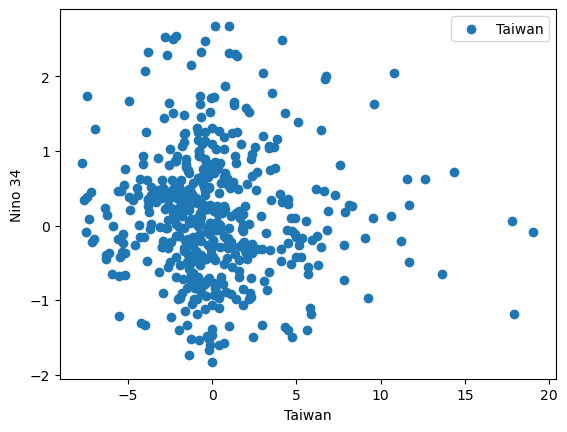

In [30]:
#scatter plot 
plt.scatter(pt_tai,ds_oni)
plt.legend(['Taiwan','Nino34'])
plt.xlabel("Taiwan")
plt.ylabel("Nino 34")
plt.show()

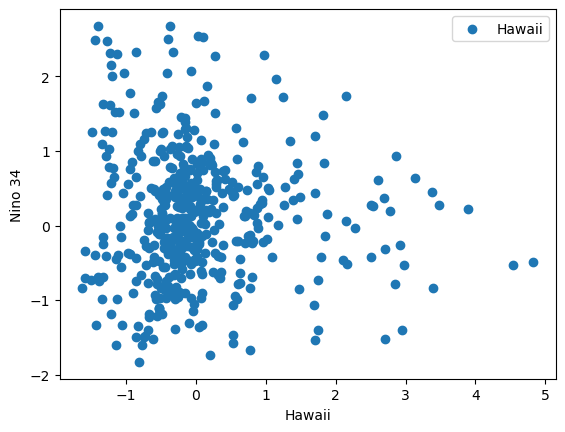

In [163]:
#scatter plot 
plt.scatter(pt_ha,ds_oni)
plt.legend(['Hawaii','Nino34'])
plt.xlabel("Hawaii")
plt.ylabel("Nino 34")

plt.show()

In [31]:
#numpy correlation function
R = np.corrcoef(pt_tai,ds_oni)
R

array([[ 1.        , -0.03162236],
       [-0.03162236,  1.        ]])

In [32]:
corr=R[0,1]
corr

-0.03162235877580134

In [166]:
#scipy correlation function 
(rvalue, pvalue) =  scipy.stats.pearsonr(pt_tai,ds_oni)
rvalue

-0.031622358775801336

In [167]:
pvalue

0.48404676041660005

Text(1.0, 1.0, 'R= -0.03*')

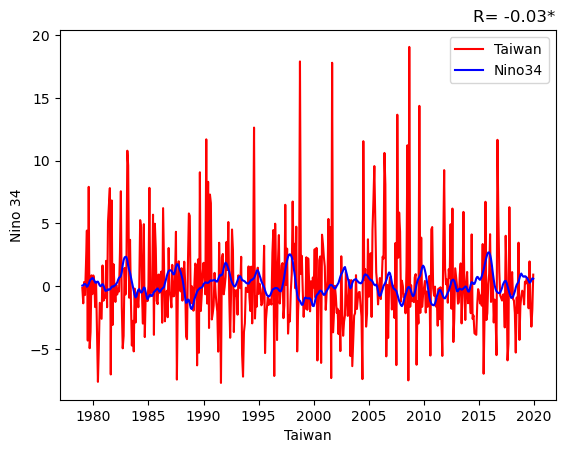

In [181]:
plt.plot(pt_tai['time'],pt_tai,'r')
plt.plot(ds_oni['time'],ds_oni,'b')
plt.legend(['Taiwan','Nino34'])
rvalue_2 = round(rvalue, 2)
stuff_in_string = f"R= {rvalue_2}*"
plt.xlabel("Taiwan")
plt.ylabel("Nino 34")
#print(stuff_in_string)
plt.title(stuff_in_string,loc='right')

In [38]:
#scipy correlation function 
(rvalue, pvalue) =  scipy.stats.pearsonr(pt_ha,ds_oni)
rvalue


-0.054695295426519866

In [39]:
pvalue

0.22588732785695517

Text(1.0, 1.0, 'R= -0.05*')

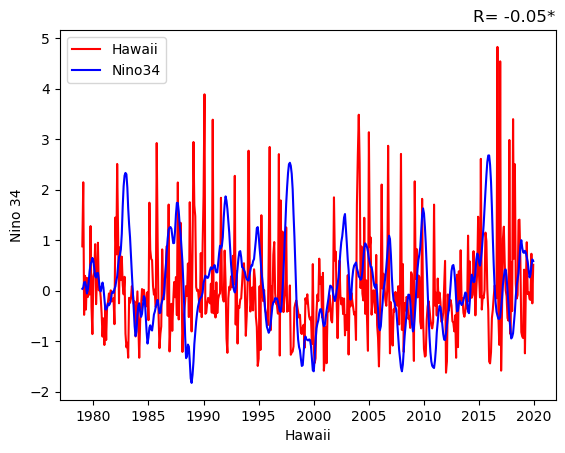

In [35]:
plt.plot(pt_ha['time'],pt_ha,'r')
plt.plot(ds_oni['time'],ds_oni,'b')
plt.legend(['Hawaii','Nino34'])
rvalue_2 = round(rvalue, 2)
stuff_in_string = f"R= {rvalue_2}*"
plt.xlabel("Hawaii")
plt.ylabel("Nino 34")
#print(stuff_in_string)
plt.title(stuff_in_string,loc='right')

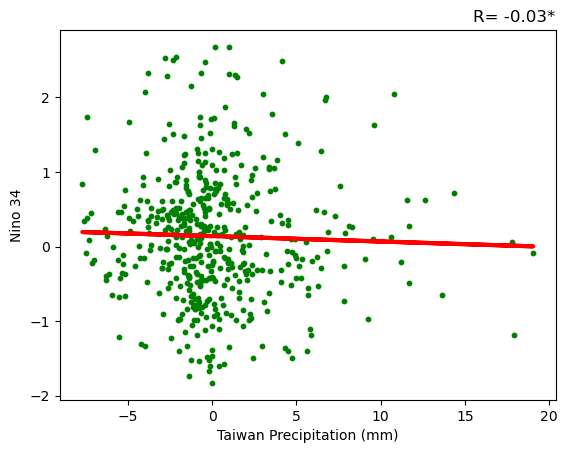

In [177]:
plt.scatter(pt_tai,ds_oni, s=10, color="green")
plt.title(stuff_in_string,loc='right')

m, b = np.polyfit(pt_tai,ds_oni, 1)
plt.plot(pt_tai, m*pt_tai + b, color="red",linewidth=3)
plt.xlabel("Taiwan Precipitation (mm)")
plt.ylabel("Nino 34")

plt.show()

#plt.plot(pt_tai['time'],pt_tai,'r')
#plt.plot(ds_oni['time'],ds_oni,'b')
#plt.legend(['Taiwan','Nino 34'])
#rvalue_2 = round(rvalue, 2)
#stuff_in_string = f"R= {rvalue_2}*"

#plt.title(stuff_in_string,loc='right')
#


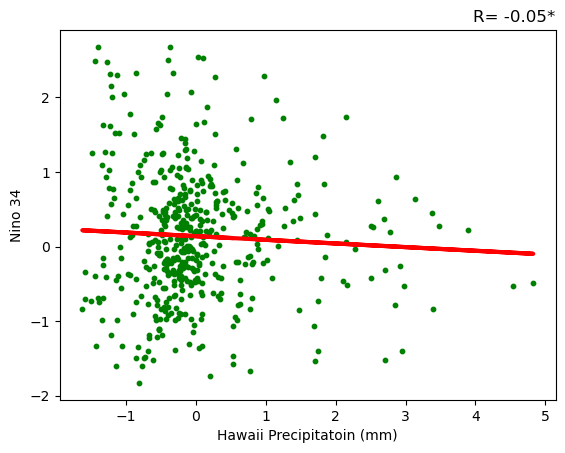

In [36]:
plt.scatter(pt_ha,ds_oni, s=10, color="green")
plt.title(stuff_in_string,loc='right')

m, b = np.polyfit(pt_ha,ds_oni, 1)
plt.plot(pt_ha, m*pt_ha + b, color="red",linewidth=3)
plt.xlabel("Hawaii Precipitatoin (mm)")
plt.ylabel("Nino 34")

plt.show()

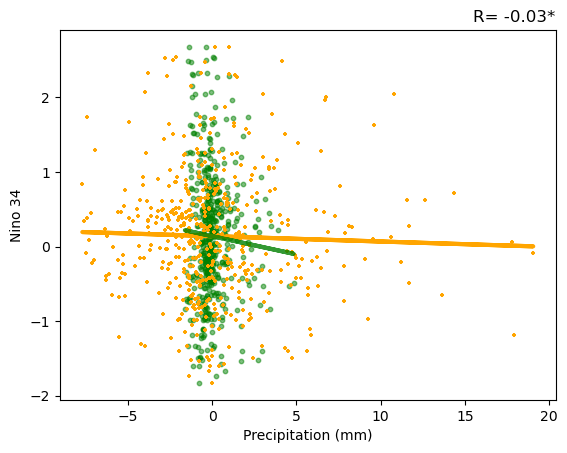

In [174]:
plt.scatter(pt_ha,ds_oni, s=10, alpha = 0.5, color="green")
plt.title(stuff_in_string,loc='right')
#
plt.scatter(pt_tai,ds_oni, s=10, marker='+', color="orange")
plt.title(stuff_in_string,loc='right')

m, b = np.polyfit(pt_tai,ds_oni, 1)
plt.plot(pt_tai, m*pt_tai + b, color="orange",linewidth=3)
#
m, b = np.polyfit(pt_ha,ds_oni, 1)
#m, b = np.polyfit(pt_tai,ds_oni, 1)
plt.plot(pt_ha, m*pt_ha + b, color="green",alpha = 0.8,linewidth=3)
plt.xlabel("Precipitation (mm)")
plt.ylabel("Nino 34")

plt.show()
